In [1]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
df.shape

(545, 13)

In [4]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


#### No Missing Values

## TASK 1 COMPLETED

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


#### No duplicates

In [7]:
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df[col] = df[col].map({'yes':1,'no':0})

In [8]:
#df = pd.get_dummies(df, columns=[ 'furnishingstatus'], dtype=int)

encoder = OneHotEncoder(sparse_output=False, dtype=int)

encoded = encoder.fit_transform(df[['furnishingstatus']])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['furnishingstatus']), index=df.index)

df = pd.concat([df.drop('furnishingstatus', axis=1), encoded_df], axis=1)

In [9]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,1,0,0


# TASK 2 COMPLETED

In [10]:
y = df['price']
X = df.drop(columns = ['price'])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [13]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = mean_squared_error(y_test, lr_pred) **0.85
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R²:", lr_r2)

Linear Regression
MAE: 970043.403920164
RMSE: 25555960967.58327
R²: 0.6529242642153185


In [14]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [15]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) **0.85
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest
MAE: 1019527.5454128442
RMSE: 28088811654.883633
R²: 0.6121105579188428


In [16]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[lr_mae, rf_mae],
    "RMSE":[lr_rmse, rf_rmse],
    "R2":[lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,9.700434e+05,2.555596e+10,0.652924
1,Random Forest,1.019528e+06,2.808881e+10,0.612111


# TASK 3 COMPLETED

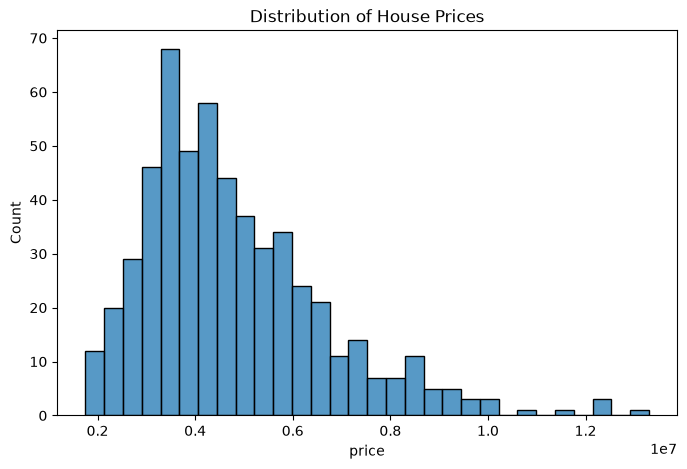

In [17]:

plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=30)

plt.title("Distribution of House Prices")
plt.savefig("charts/Price_Distribution.png")
plt.show()

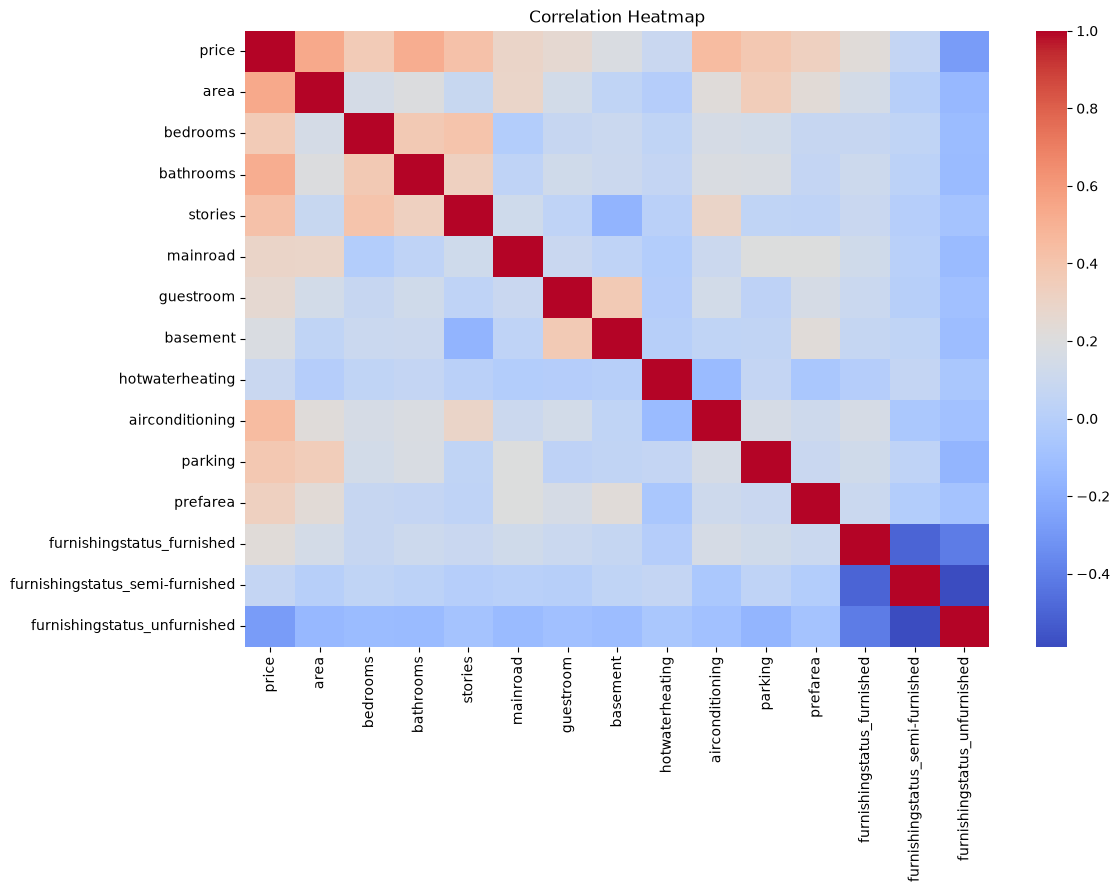

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")
plt.savefig("charts/Correlaion_Heatmap.png")
plt.show()

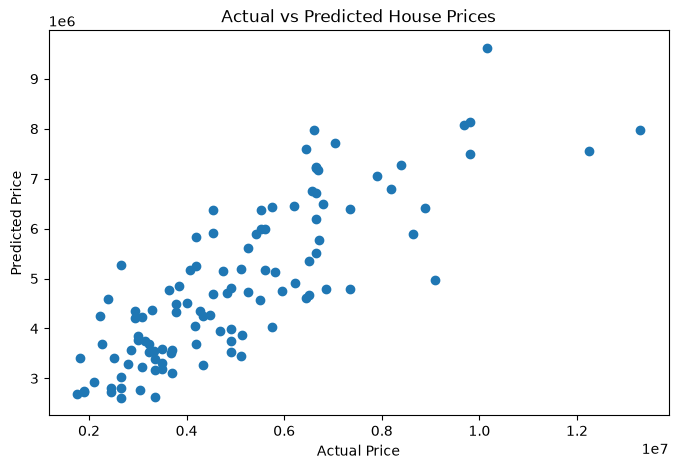

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")
plt.savefig("charts/Actual_vs_Predicted.png")
plt.show()

# TASK 4 COMPLETED

The analysis showed that area, bathrooms, air conditioning, and stories have the strongest influence on house prices. Larger homes with more amenities generally command higher prices. 

Two machine learning models were trained and compared: Linear Regression and Random Forest Regressor. Linear Regression outperformed Random Forest on this dataset, achieving a higher R² score and lower prediction errors (MAE and RMSE). This suggests that the relationship between the selected housing features and price is largely linear. 

One interesting observation was that location-related features, such as being in a preferred area and higher stories, had a noticeable impact on price even when houses were similar in size. Based on these findings, a real estate business should emphasize premium amenities and desirable locations when marketing properties, as these factors contribute significantly to higher house values.


# TASK 5 COMPLETED